# FedSafe-Crash — Day 1

The aim of this notebook is to inspect the STATS19 collision data and
examine whether police forces can be used as federated clients.

## 1. Project folders

In [1]:
from pathlib import Path

project_dir = Path("/content/fedsafe-crash")
raw_data_dir = project_dir / "data" / "raw"
results_dir = project_dir / "results"

raw_data_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir)

Project directory: /content/fedsafe-crash


## 2. Download the collision data

In [2]:
from urllib.request import urlretrieve

data_url = (
    "https://data.dft.gov.uk/road-accidents-safety-data/"
    "dft-road-casualty-statistics-collision-last-5-years.csv"
)

data_path = (
    raw_data_dir
    / "dft-road-casualty-statistics-collision-last-5-years.csv"
)

if not data_path.exists():
    urlretrieve(data_url, data_path)

print("Data path:", data_path)
print("File size:", round(data_path.stat().st_size / 1024**2, 2), "MB")

Data path: /content/fedsafe-crash/data/raw/dft-road-casualty-statistics-collision-last-5-years.csv
File size: 93.14 MB


## 3. Load the data

In [3]:
import pandas as pd

df = pd.read_csv(data_path, low_memory=False)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Rows: 513801
Columns: 44


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M102225,2025,17M102225,449804.0,519612.0,-1.23119,54.56929,17,3,1,...,-1,0,1,1,2,E01012092,3,1,0.0,1.0
1,202417S111924,2024,17S111924,444670.0,520502.0,-1.31046,54.57776,17,2,1,...,-1,0,1,1,2,E01012194,7,1,1.0,0.0
2,2025111687011,2025,111687011,427772.0,515144.0,-1.57237,54.53082,11,3,2,...,-1,0,1,3,2,E01035185,3,1,0.0,1.0
3,2025070326701,2025,070326701,351585.0,382993.0,-2.72862,53.34161,7,1,1,...,-1,0,1,1,2,E01012430,1,1,0.0,0.0
4,2025070353559,2025,070353559,351101.0,382954.0,-2.73589,53.34121,7,3,2,...,-1,0,1,2,2,E01012431,3,1,0.0,1.0


## 4. Check the main columns

In [4]:
columns_to_check = [
    "collision_index",
    "accident_year",
    "date",
    "collision_severity",
    "police_force",
    "local_authority_district",
    "urban_or_rural_area",
]

available_columns = [
    column for column in columns_to_check
    if column in df.columns
]

print("Available columns:")
print(available_columns)

Available columns:
['collision_index', 'date', 'collision_severity', 'police_force', 'local_authority_district', 'urban_or_rural_area']


## 5. Create the binary target

STATS19 severity codes:

- 1: Fatal
- 2: Serious
- 3: Slight

The binary target is defined as:

- 0: Slight
- 1: Serious or fatal

In [5]:
severity_map = {
    1: 1,
    2: 1,
    3: 0,
}

df["target_binary"] = (
    pd.to_numeric(
        df["collision_severity"],
        errors="coerce",
    )
    .map(severity_map)
    .astype("Int64")
)

class_distribution = (
    df["target_binary"]
    .value_counts(dropna=False)
    .rename_axis("target")
    .reset_index(name="count")
)

class_distribution["label"] = (
    class_distribution["target"]
    .map({
        0: "slight",
        1: "serious_or_fatal",
    })
    .fillna("missing")
)

class_distribution["proportion"] = (
    class_distribution["count"] / len(df)
)

display(class_distribution)

,target,count,label,proportion
0,0,389435,slight,0.757949
1,1,124366,serious_or_fatal,0.242051


## 6. Plot the class distribution

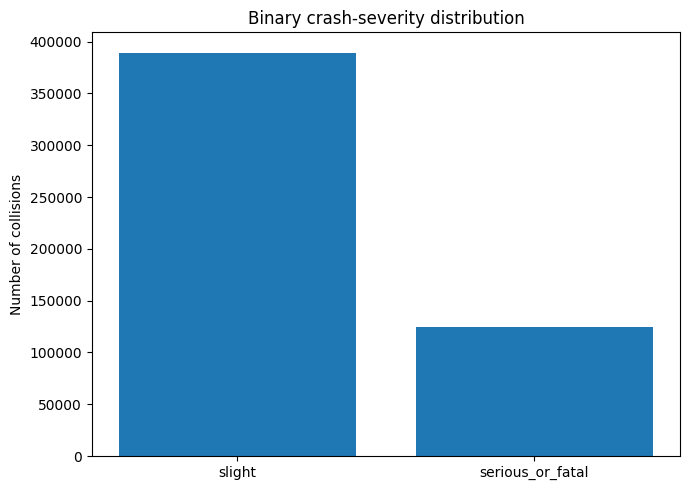

In [6]:
import matplotlib.pyplot as plt

plot_data = class_distribution[
    class_distribution["label"] != "missing"
]

plt.figure(figsize=(7, 5))
plt.bar(
    plot_data["label"],
    plot_data["count"],
)
plt.xlabel("")
plt.ylabel("Number of collisions")
plt.title("Binary crash-severity distribution")
plt.tight_layout()
plt.show()

## 7. Check the time period

In [7]:
if "accident_year" in df.columns:
    years = pd.to_numeric(
        df["accident_year"],
        errors="coerce",
    )
else:
    dates = pd.to_datetime(
        df["date"],
        dayfirst=True,
        errors="coerce",
    )
    years = dates.dt.year

print("First year:", int(years.min()))
print("Last year:", int(years.max()))

display(
    years
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="collisions")
)

First year: 2021
Last year: 2025


,year,collisions
0,2021,101087
1,2022,106004
2,2023,104258
3,2024,100927
4,2025,101525


## 8. Treat police forces as clients

Each police force is treated as one federated client.

In [8]:
client_summary = (
    df.dropna(
        subset=[
            "police_force",
            "target_binary",
        ]
    )
    .groupby("police_force")["target_binary"]
    .agg(
        samples="size",
        positive_cases="sum",
        positive_rate="mean",
    )
    .sort_index()
)

print("Number of clients:", len(client_summary))
print("Total samples:", client_summary["samples"].sum())
print("Smallest client:", client_summary["samples"].min())
print("Largest client:", client_summary["samples"].max())
print("Median client size:", client_summary["samples"].median())

display(client_summary.head())

Number of clients: 44
Total samples: 513801
Smallest client: 871
Largest client: 110585
Median client size: 8071.0


,samples,positive_cases,positive_rate
police_force,,,
1,110585,18102,0.163693
3,4035,1265,0.313507
4,13696,4517,0.329804
5,10230,2217,0.216716
6,13846,4153,0.299942


## 9. Label distribution across clients

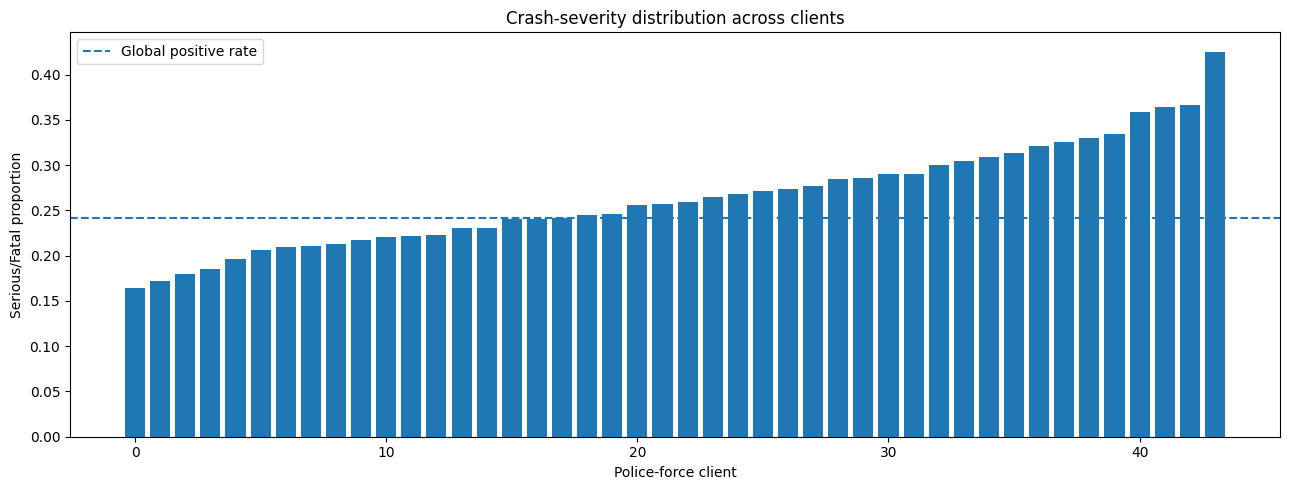

In [9]:
sorted_clients = (
    client_summary
    .sort_values("positive_rate")
    .reset_index()
)

global_positive_rate = df["target_binary"].mean()

plt.figure(figsize=(13, 5))
plt.bar(
    range(len(sorted_clients)),
    sorted_clients["positive_rate"],
)
plt.axhline(
    global_positive_rate,
    linestyle="--",
    label="Global positive rate",
)
plt.xlabel("Police-force client")
plt.ylabel("Serious/Fatal proportion")
plt.title("Crash-severity distribution across clients")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Client size and positive rate

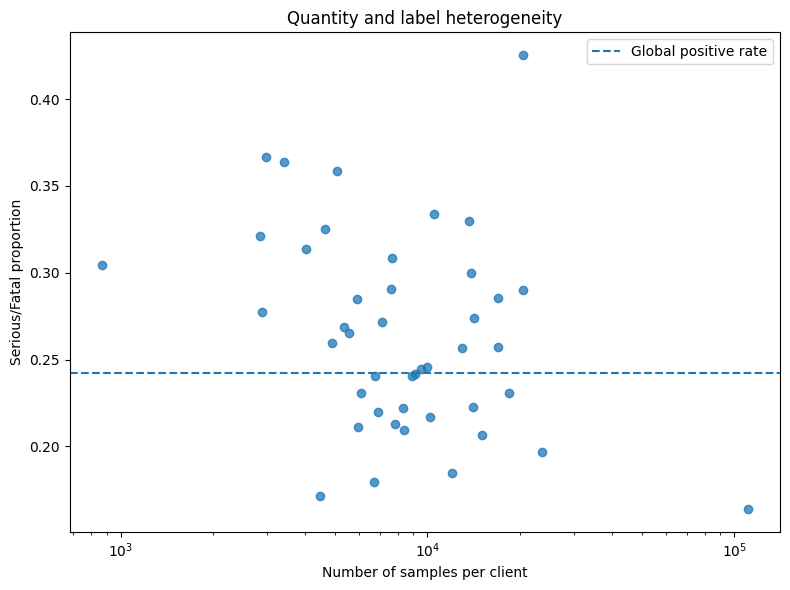

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    client_summary["samples"],
    client_summary["positive_rate"],
    alpha=0.75,
)
plt.axhline(
    global_positive_rate,
    linestyle="--",
    label="Global positive rate",
)
plt.xscale("log")
plt.xlabel("Number of samples per client")
plt.ylabel("Serious/Fatal proportion")
plt.title("Quantity and label heterogeneity")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Clients with the lowest and highest positive rates

In [11]:
print("Lowest positive rates")
display(
    client_summary
    .sort_values("positive_rate")
    .head(10)
)

print("Highest positive rates")
display(
    client_summary
    .sort_values("positive_rate")
    .tail(10)
)

Lowest positive rates


,samples,positive_cases,positive_rate
police_force,,,
1,110585,18102,0.163693
62,4450,763,0.171461
54,6677,1200,0.179721
52,12018,2222,0.184889
20,23672,4659,0.196815
43,15062,3111,0.206546
41,8375,1754,0.209433
40,5958,1257,0.210977
7,7849,1670,0.212766


Highest positive rates


,samples,positive_cases,positive_rate
police_force,,,
22,7662,2364,0.308536
3,4035,1265,0.313507
61,2847,915,0.321391
53,4642,1510,0.325291
4,13696,4517,0.329804
14,10495,3506,0.334064
63,5075,1819,0.358424
60,3415,1243,0.363982
11,2969,1089,0.36679


## 12. Save the Day 1 outputs

In [12]:
class_distribution.to_csv(
    results_dir / "class_distribution.csv",
    index=False,
)

client_summary.to_csv(
    results_dir / "client_summary.csv",
)

day1_summary = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "number_of_clients": int(len(client_summary)),
    "global_positive_rate": float(global_positive_rate),
    "smallest_client": int(
        client_summary["samples"].min()
    ),
    "largest_client": int(
        client_summary["samples"].max()
    ),
    "median_client_size": float(
        client_summary["samples"].median()
    ),
    "minimum_client_positive_rate": float(
        client_summary["positive_rate"].min()
    ),
    "maximum_client_positive_rate": float(
        client_summary["positive_rate"].max()
    ),
}

import json

with open(
    results_dir / "day1_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        day1_summary,
        file,
        indent=2,
    )

print(day1_summary)
print("Results saved in:", results_dir)

{'rows': 513801, 'columns': 45, 'number_of_clients': 44, 'global_positive_rate': 0.2420509107611702, 'smallest_client': 871, 'largest_client': 110585, 'median_client_size': 8071.0, 'minimum_client_positive_rate': 0.16369308676583624, 'maximum_client_positive_rate': 0.4253287871407696}
Results saved in: /content/fedsafe-crash/results


## Day 1 conclusion

The data are suitable for a federated learning experiment because police
forces differ in both sample size and crash-severity distribution.

In [13]:
# Day 2 — Data Preparation

In [14]:
if "accident_year" in df.columns:
    df["year"] = pd.to_numeric(
        df["accident_year"],
        errors="coerce"
    )
else:
    df["year"] = pd.to_datetime(
        df["date"],
        dayfirst=True,
        errors="coerce"
    ).dt.year

year_counts = (
    df["year"]
    .value_counts()
    .sort_index()
)

print(year_counts)

year
2021    101087
2022    106004
2023    104258
2024    100927
2025    101525
Name: count, dtype: int64


In [15]:
date = pd.to_datetime(
    df["date"],
    dayfirst=True,
    errors="coerce"
)

time = pd.to_datetime(
    df["time"],
    format="%H:%M",
    errors="coerce"
)

df["month"] = date.dt.month
df["hour"] = time.dt.hour

In [16]:
display(
    df[
        [
            "date",
            "time",
            "year",
            "month",
            "hour"
        ]
    ].head()
)

,date,time,year,month,hour
0,15/02/2025,19:15,2025,2,19
1,22/10/2024,14:48,2024,10,14
2,19/12/2025,06:40,2025,12,6
3,22/04/2025,20:03,2025,4,20
4,28/04/2025,17:40,2025,4,17


In [17]:
candidate_features = [
    "number_of_vehicles",
    "speed_limit",
    "day_of_week",
    "road_type",
    "junction_detail",
    "junction_control",
    "pedestrian_crossing_human_control",
    "pedestrian_crossing_physical_facilities",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "special_conditions_at_site",
    "carriageway_hazards",
    "urban_or_rural_area",
    "month",
    "hour"
]

In [18]:
features = [
    column
    for column in candidate_features
    if column in df.columns
]

print("Number of features:", len(features))

for feature in features:
    print(feature)

Number of features: 14
number_of_vehicles
speed_limit
day_of_week
road_type
junction_detail
junction_control
light_conditions
weather_conditions
road_surface_conditions
special_conditions_at_site
carriageway_hazards
urban_or_rural_area
month
hour


In [19]:
client_column = "police_force"
target_column = "target_binary"

columns_needed = (
    [client_column, "year"]
    + features
    + [target_column]
)

model_data = df[
    columns_needed
].copy()

In [20]:
model_data = model_data.dropna(
    subset=[
        client_column,
        "year",
        target_column
    ]
)

In [21]:
model_data[client_column] = (
    model_data[client_column]
    .astype(int)
)

model_data["year"] = (
    model_data["year"]
    .astype(int)
)

In [22]:
print(model_data.shape)

display(model_data.head())

(513801, 17)


,police_force,year,number_of_vehicles,speed_limit,day_of_week,road_type,junction_detail,junction_control,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,month,hour,target_binary
0,17,2025,1,30,7,6,16,4,4,1,1,-1,0,1,2,19,0
1,17,2024,1,30,3,6,0,-1,1,1,1,-1,0,1,10,14,1
2,11,2025,2,30,6,6,13,4,4,2,2,-1,0,1,12,6,0
3,7,2025,1,30,3,6,0,-1,1,1,1,-1,0,1,4,20,1
4,7,2025,2,30,2,6,16,4,1,1,1,-1,0,1,4,17,0


In [23]:
years = sorted(
    model_data["year"].unique()
)

train_years = years[:-2]
validation_year = years[-2]
test_year = years[-1]

print("Train:", train_years)
print("Validation:", validation_year)
print("Test:", test_year)

Train: [np.int64(2021), np.int64(2022), np.int64(2023)]
Validation: 2024
Test: 2025


In [24]:
train_df = model_data[
    model_data["year"].isin(train_years)
].copy()

val_df = model_data[
    model_data["year"] == validation_year
].copy()

test_df = model_data[
    model_data["year"] == test_year
].copy()

In [25]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (311349, 17)
Validation: (100927, 17)
Test: (101525, 17)


In [26]:
def client_summary(frame, split_name):
    summary = (
        frame
        .groupby("police_force")["target_binary"]
        .agg(
            samples="size",
            positive_cases="sum",
            positive_rate="mean"
        )
        .reset_index()
    )

    summary["split"] = split_name

    return summary


client_split_summary = pd.concat(
    [
        client_summary(train_df, "train"),
        client_summary(val_df, "validation"),
        client_summary(test_df, "test")
    ],
    ignore_index=True
)

display(client_split_summary.head(15))

,police_force,samples,positive_cases,positive_rate,split
0,1,69059,10764,0.155867,train
1,3,2460,770,0.313008,train
2,4,8242,2737,0.33208,train
3,5,6395,1359,0.21251,train
4,6,8342,2256,0.270439,train
5,7,4815,887,0.184216,train
6,10,5544,1323,0.238636,train
7,11,1823,644,0.353264,train
8,12,3928,927,0.235998,train
9,13,12530,3592,0.286672,train


In [27]:
client_presence = (
    client_split_summary
    .pivot(
        index="police_force",
        columns="split",
        values="samples"
    )
    .fillna(0)
    .astype(int)
)

display(client_presence)

print("Number of clients:", len(client_presence))

print(
    "Clients available in all splits:",
    (
        (client_presence["train"] > 0)
        & (client_presence["validation"] > 0)
        & (client_presence["test"] > 0)
    ).sum()
)

split,test,train,validation
police_force,,,
1,20692,69059,20834
3,781,2460,794
4,2723,8242,2731
5,1933,6395,1902
6,2711,8342,2793
7,1559,4815,1475
10,1753,5544,1834
11,575,1823,571
12,1472,3928,1347


Number of clients: 44
Clients available in all splits: 44


In [28]:
print("Smallest train clients:")
display(
    client_split_summary[
        client_split_summary["split"] == "train"
    ]
    .sort_values("samples")
    .head(10)
)

print("Smallest validation clients:")
display(
    client_split_summary[
        client_split_summary["split"] == "validation"
    ]
    .sort_values("samples")
    .head(10)
)

print("Smallest test clients:")
display(
    client_split_summary[
        client_split_summary["split"] == "test"
    ]
    .sort_values("samples")
    .head(10)
)

Smallest train clients:


,police_force,samples,positive_cases,positive_rate,split
33,48,496,145,0.292339,train
40,61,1698,552,0.325088,train
7,11,1823,644,0.353264,train
12,17,1904,485,0.254727,train
14,21,2209,671,0.303757,train
39,60,2359,777,0.329377,train
1,3,2460,770,0.313008,train
16,23,2715,698,0.25709,train
36,53,2755,963,0.349546,train
41,62,2852,478,0.167602,train


Smallest validation clients:


,police_force,samples,positive_cases,positive_rate,split
77,48,166,54,0.325301,validation
56,17,500,144,0.288,validation
83,60,521,213,0.408829,validation
84,61,569,184,0.323374,validation
51,11,571,222,0.388792,validation
45,3,794,245,0.308564,validation
85,62,799,126,0.157697,validation
86,63,1024,429,0.418945,validation
80,53,1030,268,0.260194,validation
60,23,1092,288,0.263736,validation


Smallest test clients:


,police_force,samples,positive_cases,positive_rate,split
121,48,209,66,0.315789,test
100,17,488,173,0.354508,test
127,60,535,253,0.472897,test
95,11,575,223,0.387826,test
128,61,580,179,0.308621,test
89,3,781,250,0.320102,test
129,62,799,159,0.198999,test
124,53,857,279,0.325554,test
104,23,1082,284,0.262477,test
130,63,1089,470,0.431589,test
